# Figure 3 panels

## Authors:
  *  *Anton Safonov*
  *  *Luca Boscolo Bielo*
  *  *David Brown*



## Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib as mpl
from datetime import datetime

## Plot

In [2]:
#load data
df = pd.read_csv('../data/Supp_Fig3i.csv', index_col=0)
df.rename(columns = {
    'estimate':'HR', 
    'p.value':'p',
    'conf.low':'CI.low',
    'conf.high':'CI.high',
}, inplace=True)
df.index = ['RB1_Other_LOH_uni', 
            'RB1_het_loss_uni', 
            'RB1_Other_LOH',
            'RB1_het_loss', 
            'RB1_OS_Other_LOH',
            'RB1_OS_het_loss',
            'RB1_OS_Other_LOH_multi', 
            'RB1_OS_het_loss_multi'
            ]
df.index.name = 'comparison'

In [3]:
#reorder rows in desired plotting order
order = [
    'RB1_het_loss_uni',
    'RB1_het_loss',
    'RB1_Other_LOH_uni',
    'RB1_Other_LOH', 
    'RB1_OS_het_loss',
    'RB1_OS_het_loss_multi',
    'RB1_OS_Other_LOH',
    'RB1_OS_Other_LOH_multi'
]
df  = df.reindex(order)
df.reset_index(inplace=True)

#for palette
df = df.assign(analysis = lambda x: ['uni' if 'uni' in analysis else 'multi' for analysis in x['analysis']])\
    .rename(columns={'analysis':'Uni_Multi'})

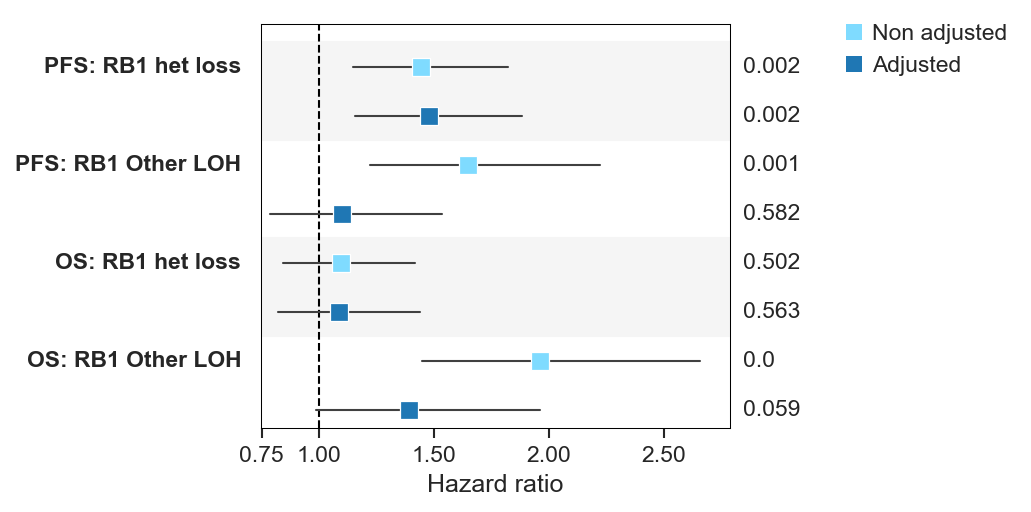

In [4]:
plot_df = df.copy()

plot_df[['HR', 'CI.low', 'CI.high', 'p']] = plot_df[['HR', 'CI.low', 'CI.high', 'p']].round(3)

ypos = np.arange(len(plot_df)) 
plot_df['ypos'] = ypos
palette = {'uni': '#7FDBFF',      
           'multi': '#1f77b4'}   
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=150)

for i in range(0, len(plot_df), 4):
    ax.axhspan(i-0.5, i+1.5, color='0.96', zorder=0)

ax.axvline(1, ls='--', lw=1, color='black', zorder=1)


for _, r in plot_df.iterrows():
    # CI bar
    ax.plot([r['CI.low'], r['CI.high']], [r['ypos'], r['ypos']],
            color='0.25', lw=1, solid_capstyle='round', zorder=2)
    # square marker 
    ax.scatter(r['HR'], r['ypos'],
               s=70, marker='s',
               color=palette.get(r['Uni_Multi'], '#1f77b4'),
               edgecolor='white', linewidth=0.6,
               zorder=3)

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df['comparison'])
ax.invert_yaxis()  
ax.grid(False)
#manual reannotation of labels
ax.set_yticklabels(
    [
    'PFS: RB1 het loss',
    '',
    'PFS: RB1 Other LOH',
    '',
    'OS: RB1 het loss',
    '',
    'OS: RB1 Other LOH',
    ''],
    fontsize=11, 
    fontweight='bold', 
    va ='center')

ax.set_xticks([0.75, 1, 1.5, 2, 2.5])
ax.tick_params(axis='x',
               which='major',
               bottom=True, top=False,    
               length=5, width=1,         
               direction='out')


ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')

# x range
xmin = max(0.1, plot_df['CI.low'].min()*0.95)
xmax = plot_df['CI.high'].max()*1.05
ax.set_xlim(xmin, xmax)
ax.set_xlabel('Hazard ratio')
ax.set_ylabel('')

for _, r in plot_df.iterrows():
    ax.text(xmax*1.02, r['ypos'], f"{r['p']}",
            va='center', ha='left', fontsize=11)

plt.subplots_adjust(right=0.82)

from matplotlib.lines import Line2D
square = dict(linestyle='None', marker='s', markersize=8, markeredgecolor='none')
handles = [
    Line2D([0], [0], **square, markerfacecolor=palette['uni'],  label='Non adjusted'),
    Line2D([0], [0], **square, markerfacecolor=palette['multi'], label='Adjusted'),
]
ax.legend(handles=handles,
          loc='upper left', bbox_to_anchor=(1.2, 1.05),
          frameon=False, handlelength=0.8, handletextpad=0.4, 
          fontsize=11
          )

mpl.rcParams['font.family'] = 'Arial'  

# plt.savefig('/Users/boscoll/Desktop/Projects/Anton_RB1/results/forest_plot_18Dec.svg', bbox_inches='tight')
plt.show()

In [5]:
print(f"Last run on: {datetime.now().strftime('%Y-%m-%d')}")
print("-" * 30)
print(f"Pandas: {pd.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Matplotlib: {mpl.__version__}")

Last run on: 2025-12-27
------------------------------
Pandas: 2.3.3
Seaborn: 0.13.2
Matplotlib: 3.10.6
